# 04 — Evaluation: SHAP Analysis, Error Analysis & Model Comparison

**TFM: Demand Forecasting for Inventory Management Using Machine Learning**

Author: Ona Mas i Serra

This notebook performs SHAP feature importance analysis on the best model (LightGBM),
detailed error analysis across models, per-product RMSE distributions,
and promo vs non-promo performance comparison.


## Setup & Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import shap
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import sys
sys.path.insert(0, '/Users/omasiser/Library/CloudStorage/OneDrive-amazon.com/UOC/TFM forecasting/knowledge base/TFM_Ona_Code')
from style_config import (apply_style, PRIMARY, SECONDARY, NEUTRAL, ALERT,
                          get_model_color, get_model_colors)

%matplotlib inline

BASE_DIR = Path('/Users/omasiser/Library/CloudStorage/OneDrive-amazon.com/UOC/TFM forecasting/knowledge base/TFM_Ona_Code')
FEATURES_PATH = BASE_DIR / 'output' / 'processed' / 'features.parquet'
PREDS_PATH = BASE_DIR / 'output' / 'models' / 'predictions_last_fold.parquet'
PARAMS_PATH = BASE_DIR / 'output' / 'models' / 'tuned_params.json'
OUTPUT_DIR = BASE_DIR / 'output' / 'evaluation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_style()

TARGET = 'udsVenta'
EXCLUDE = ['producto', 'idSecuencia', 'fecha', 'day_name', TARGET,
           'prod_mean_sales', 'prod_std_sales', 'prod_median_sales']

def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{name}.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f'   \u2192 Saved {name}.png')

def calc_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    errors = y_true - y_pred
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs(errors[mask] / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    sigma_e = np.std(errors)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sigma_e': sigma_e}


## 1. Load Data & Retrain LightGBM

Load the feature-engineered data and predictions from the modelling step,
then retrain LightGBM on the train split for SHAP analysis.


In [2]:
print('=' * 60)
print('1. LOADING DATA & RETRAINING LightGBM')
print('=' * 60)

df = pd.read_parquet(FEATURES_PATH)
preds = pd.read_parquet(PREDS_PATH)
with open(PARAMS_PATH) as f:
    params = json.load(f)

feature_cols = [c for c in df.columns if c not in EXCLUDE]

all_dates = sorted(df['fecha'].unique())
cutoff = all_dates[-30]
train = df[df['fecha'] < cutoff]
test = df[df['fecha'] >= cutoff]

X_train, y_train = train[feature_cols], train[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]

lgb_params = params['lgb']
model = lgb.LGBMRegressor(**lgb_params)
model.fit(X_train, y_train)
print(f'Train: {len(train):,} | Test: {len(test):,}')


1. LOADING DATA & RETRAINING LightGBM


Train: 579,453 | Test: 25,830


## 2. SHAP Feature Importance

Compute SHAP values using TreeExplainer on a sample of the test set.
Generate beeswarm summary, bar plot, importance table, and dependence plots for top 4 features.



2. SHAP FEATURE IMPORTANCE
Generating SHAP summary plot...


/var/folders/n_/9zp1khbj0j7_b4xf1q304vvh0000gq/T/ipykernel_59587/1181906898.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=False, max_display=20)


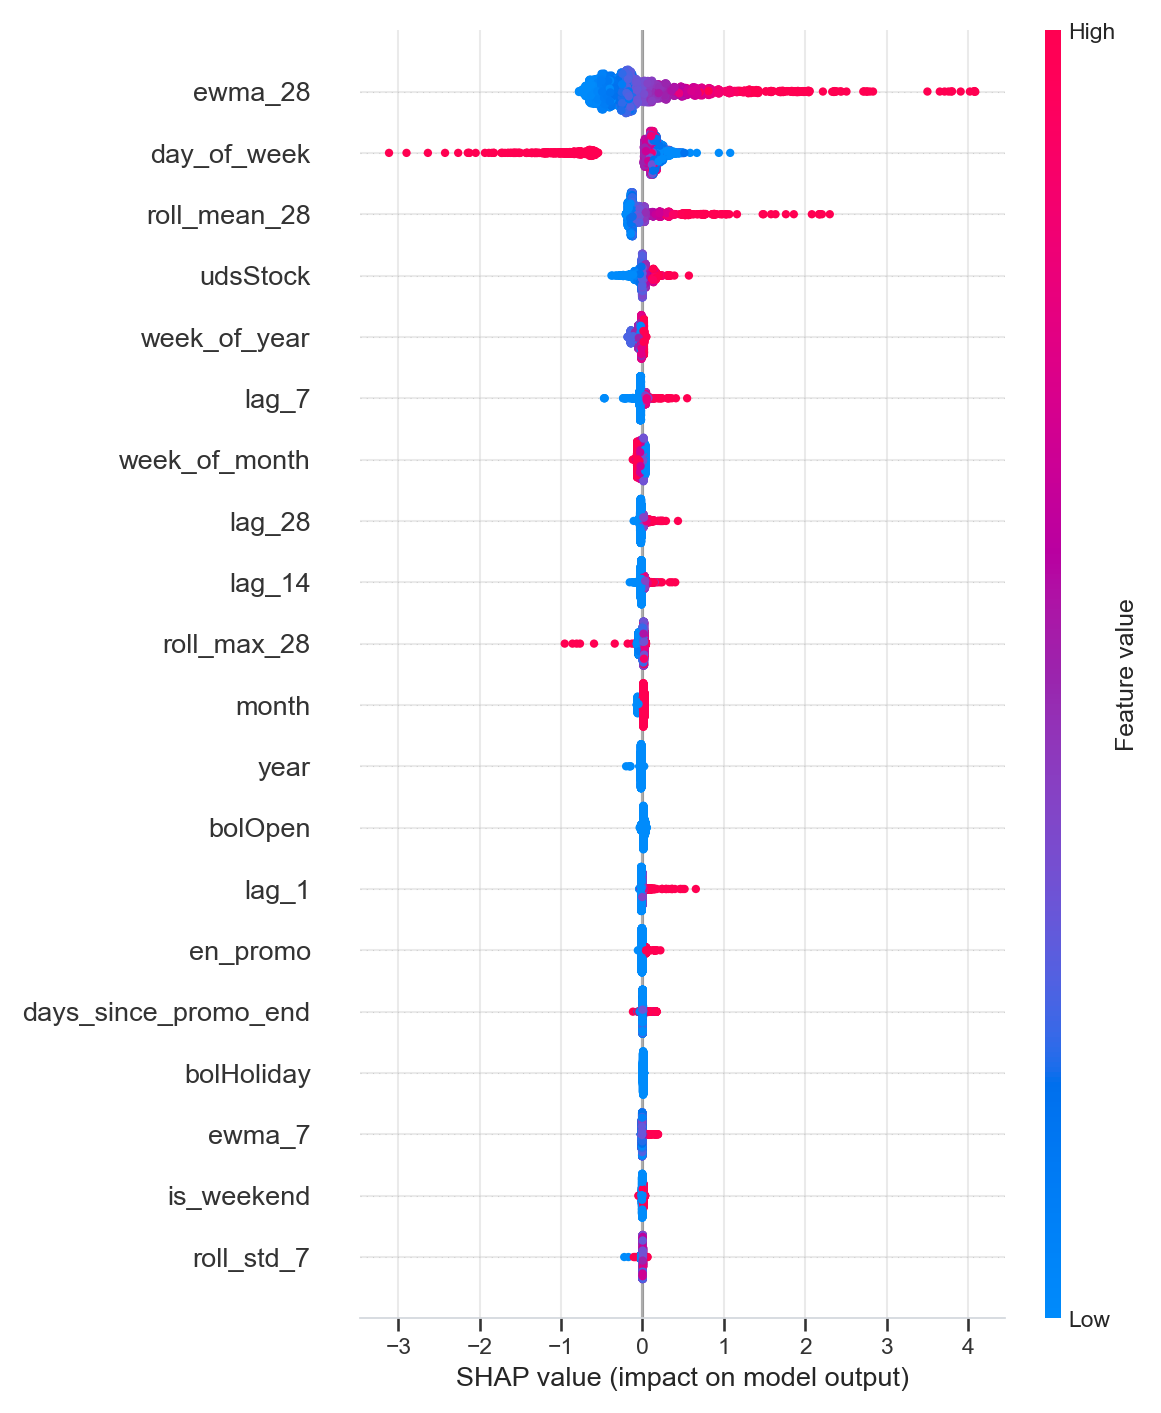

   → Saved 14_shap_summary.png


/var/folders/n_/9zp1khbj0j7_b4xf1q304vvh0000gq/T/ipykernel_59587/1181906898.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20,


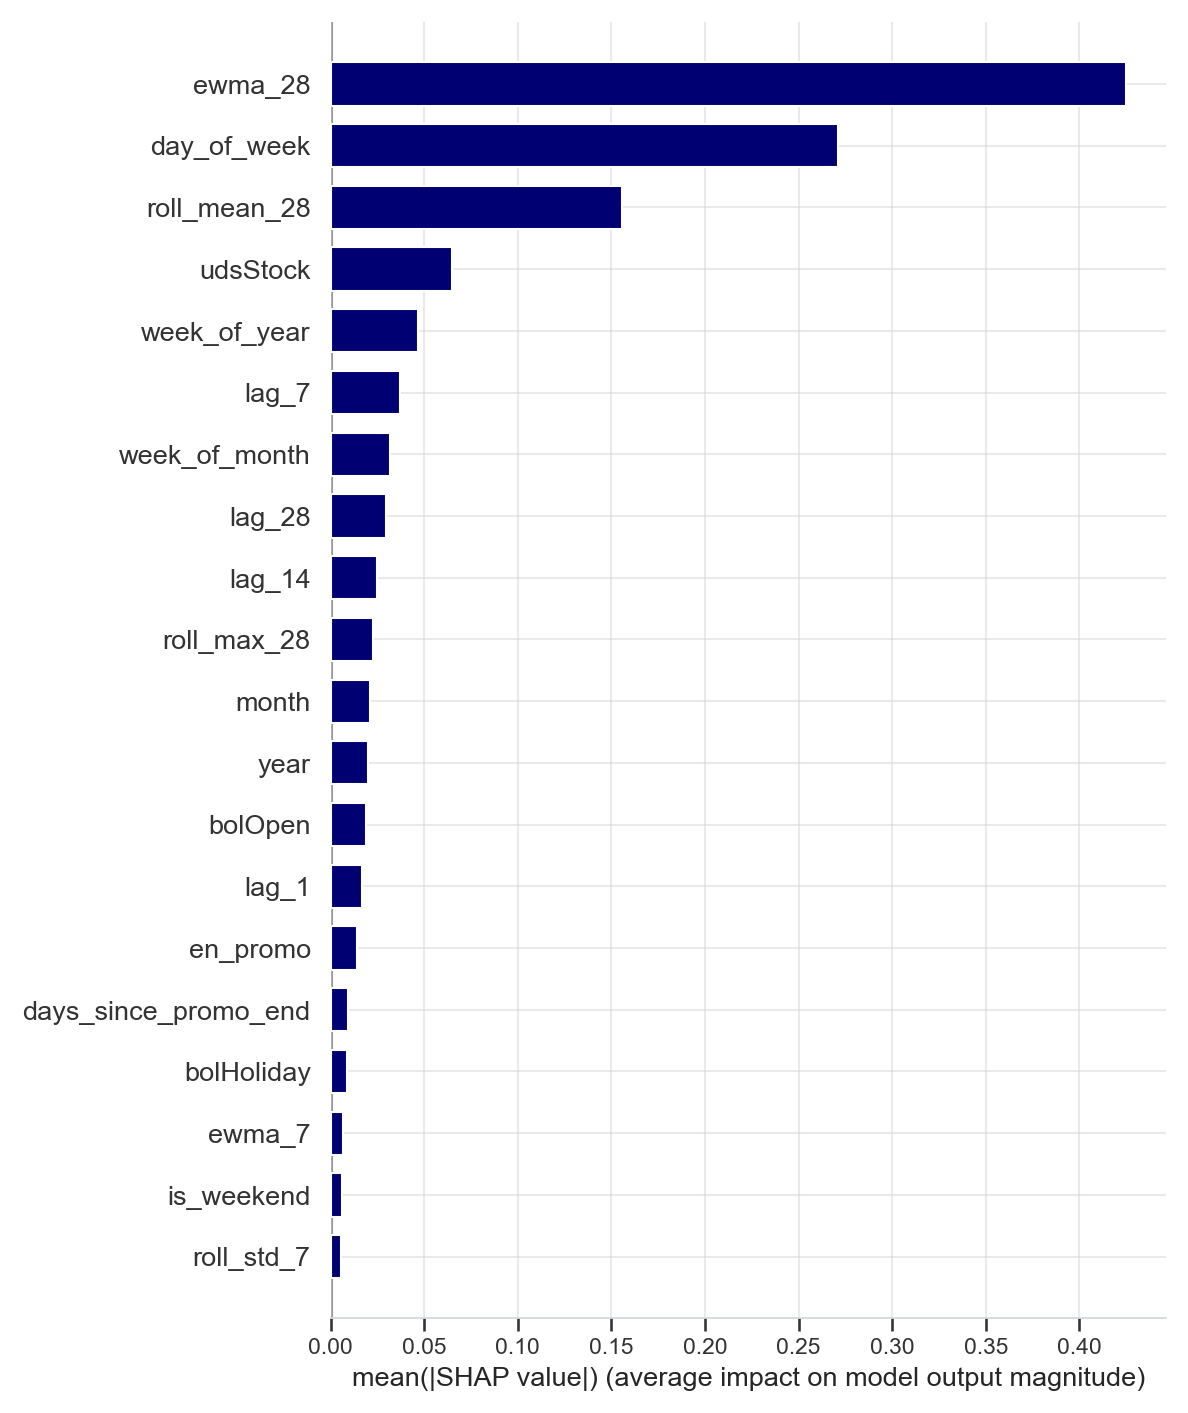

   → Saved 15_shap_bar.png

── Top 15 Features by Mean |SHAP| ──
      feature  mean_abs_shap
      ewma_28       0.424902
  day_of_week       0.271124
 roll_mean_28       0.155521
     udsStock       0.065101
 week_of_year       0.046811
        lag_7       0.037352
week_of_month       0.031582
       lag_28       0.029676
       lag_14       0.025078
  roll_max_28       0.022749
        month       0.020985
         year       0.019791
      bolOpen       0.019042
        lag_1       0.016640
     en_promo       0.014354


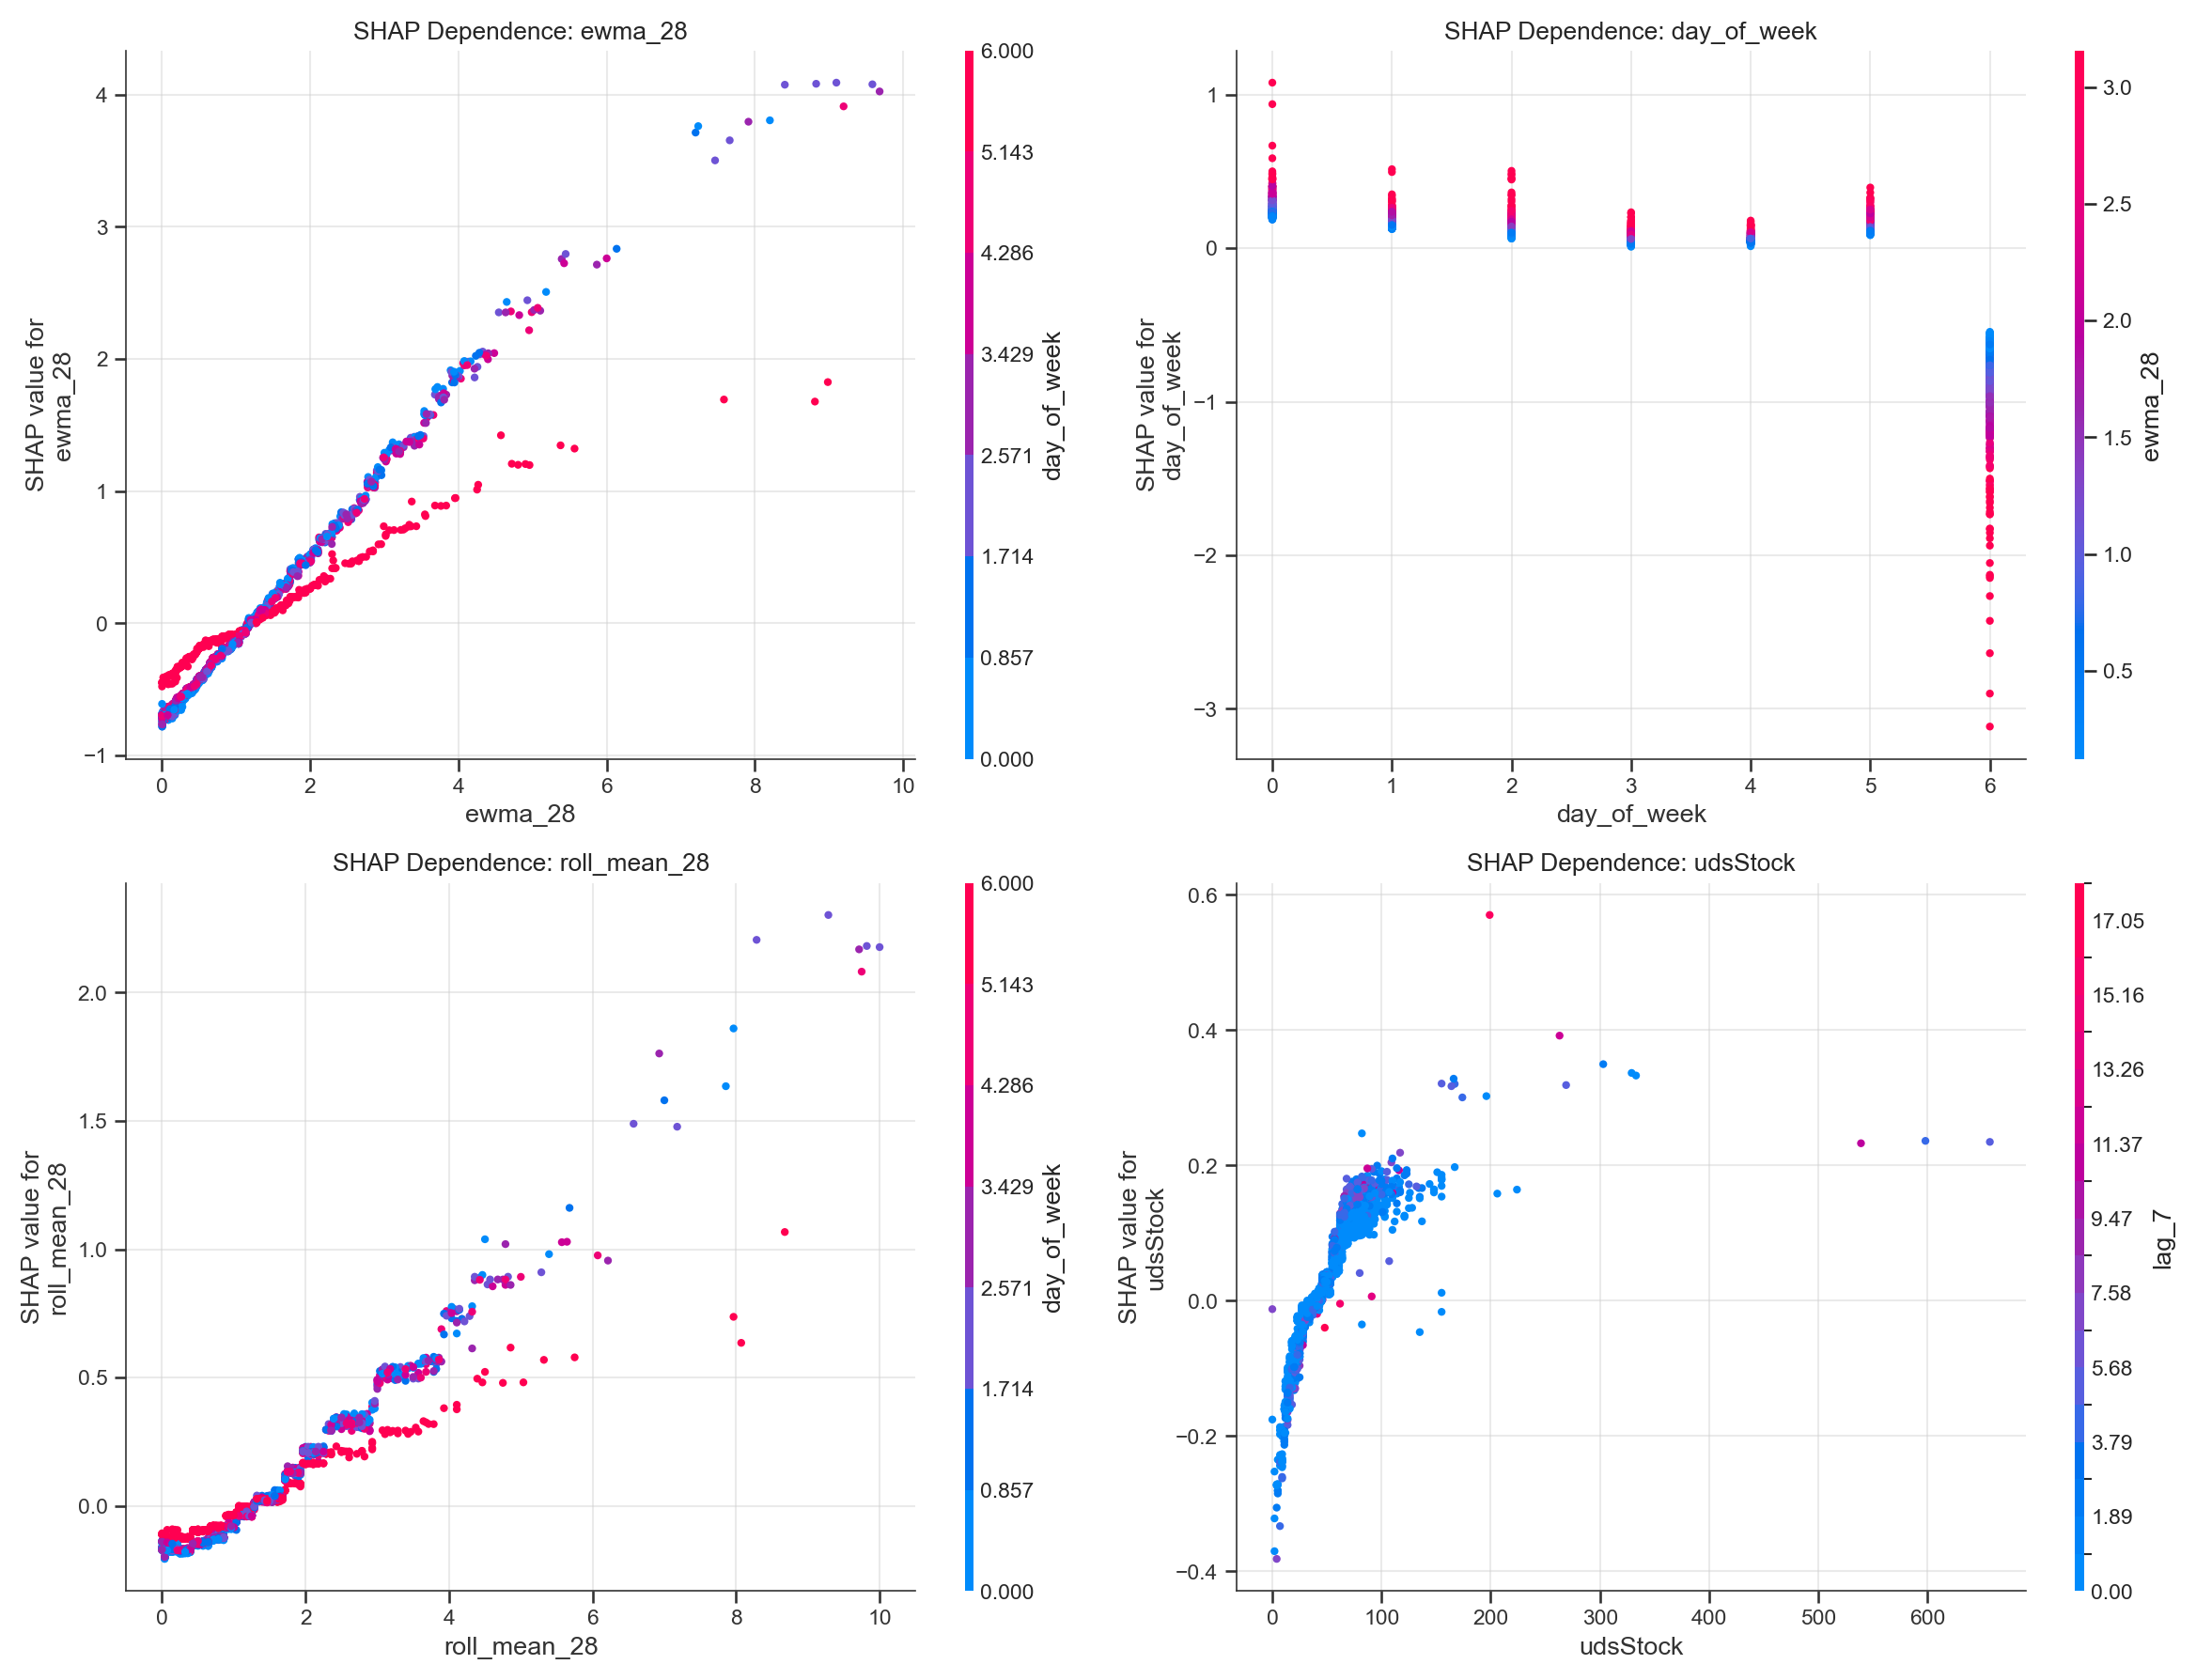

   → Saved 16_shap_dependence_top4.png


In [3]:
print('\n' + '=' * 60)
print('2. SHAP FEATURE IMPORTANCE')
print('=' * 60)

np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_shap = X_test.iloc[shap_sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# 2.1 SHAP summary (beeswarm)
print('Generating SHAP summary plot...')
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
save_fig('14_shap_summary')

# 2.2 SHAP bar plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20,
                  color=PRIMARY)
save_fig('15_shap_bar')

# 2.3 SHAP values table
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('\n\u2500\u2500 Top 15 Features by Mean |SHAP| \u2500\u2500')
print(shap_importance.head(15).to_string(index=False))
shap_importance.to_csv(OUTPUT_DIR / 'shap_importance.csv', index=False)

# 2.4 SHAP dependence plots for top 4 features
top4 = shap_importance['feature'].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, feat in zip(axes.flat, top4):
    shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')
save_fig('16_shap_dependence_top4')


## 3. Error Analysis

Error distributions per model, per-product RMSE distributions,
products with most/least improvement over naive, and error by day of week.



3. ERROR ANALYSIS


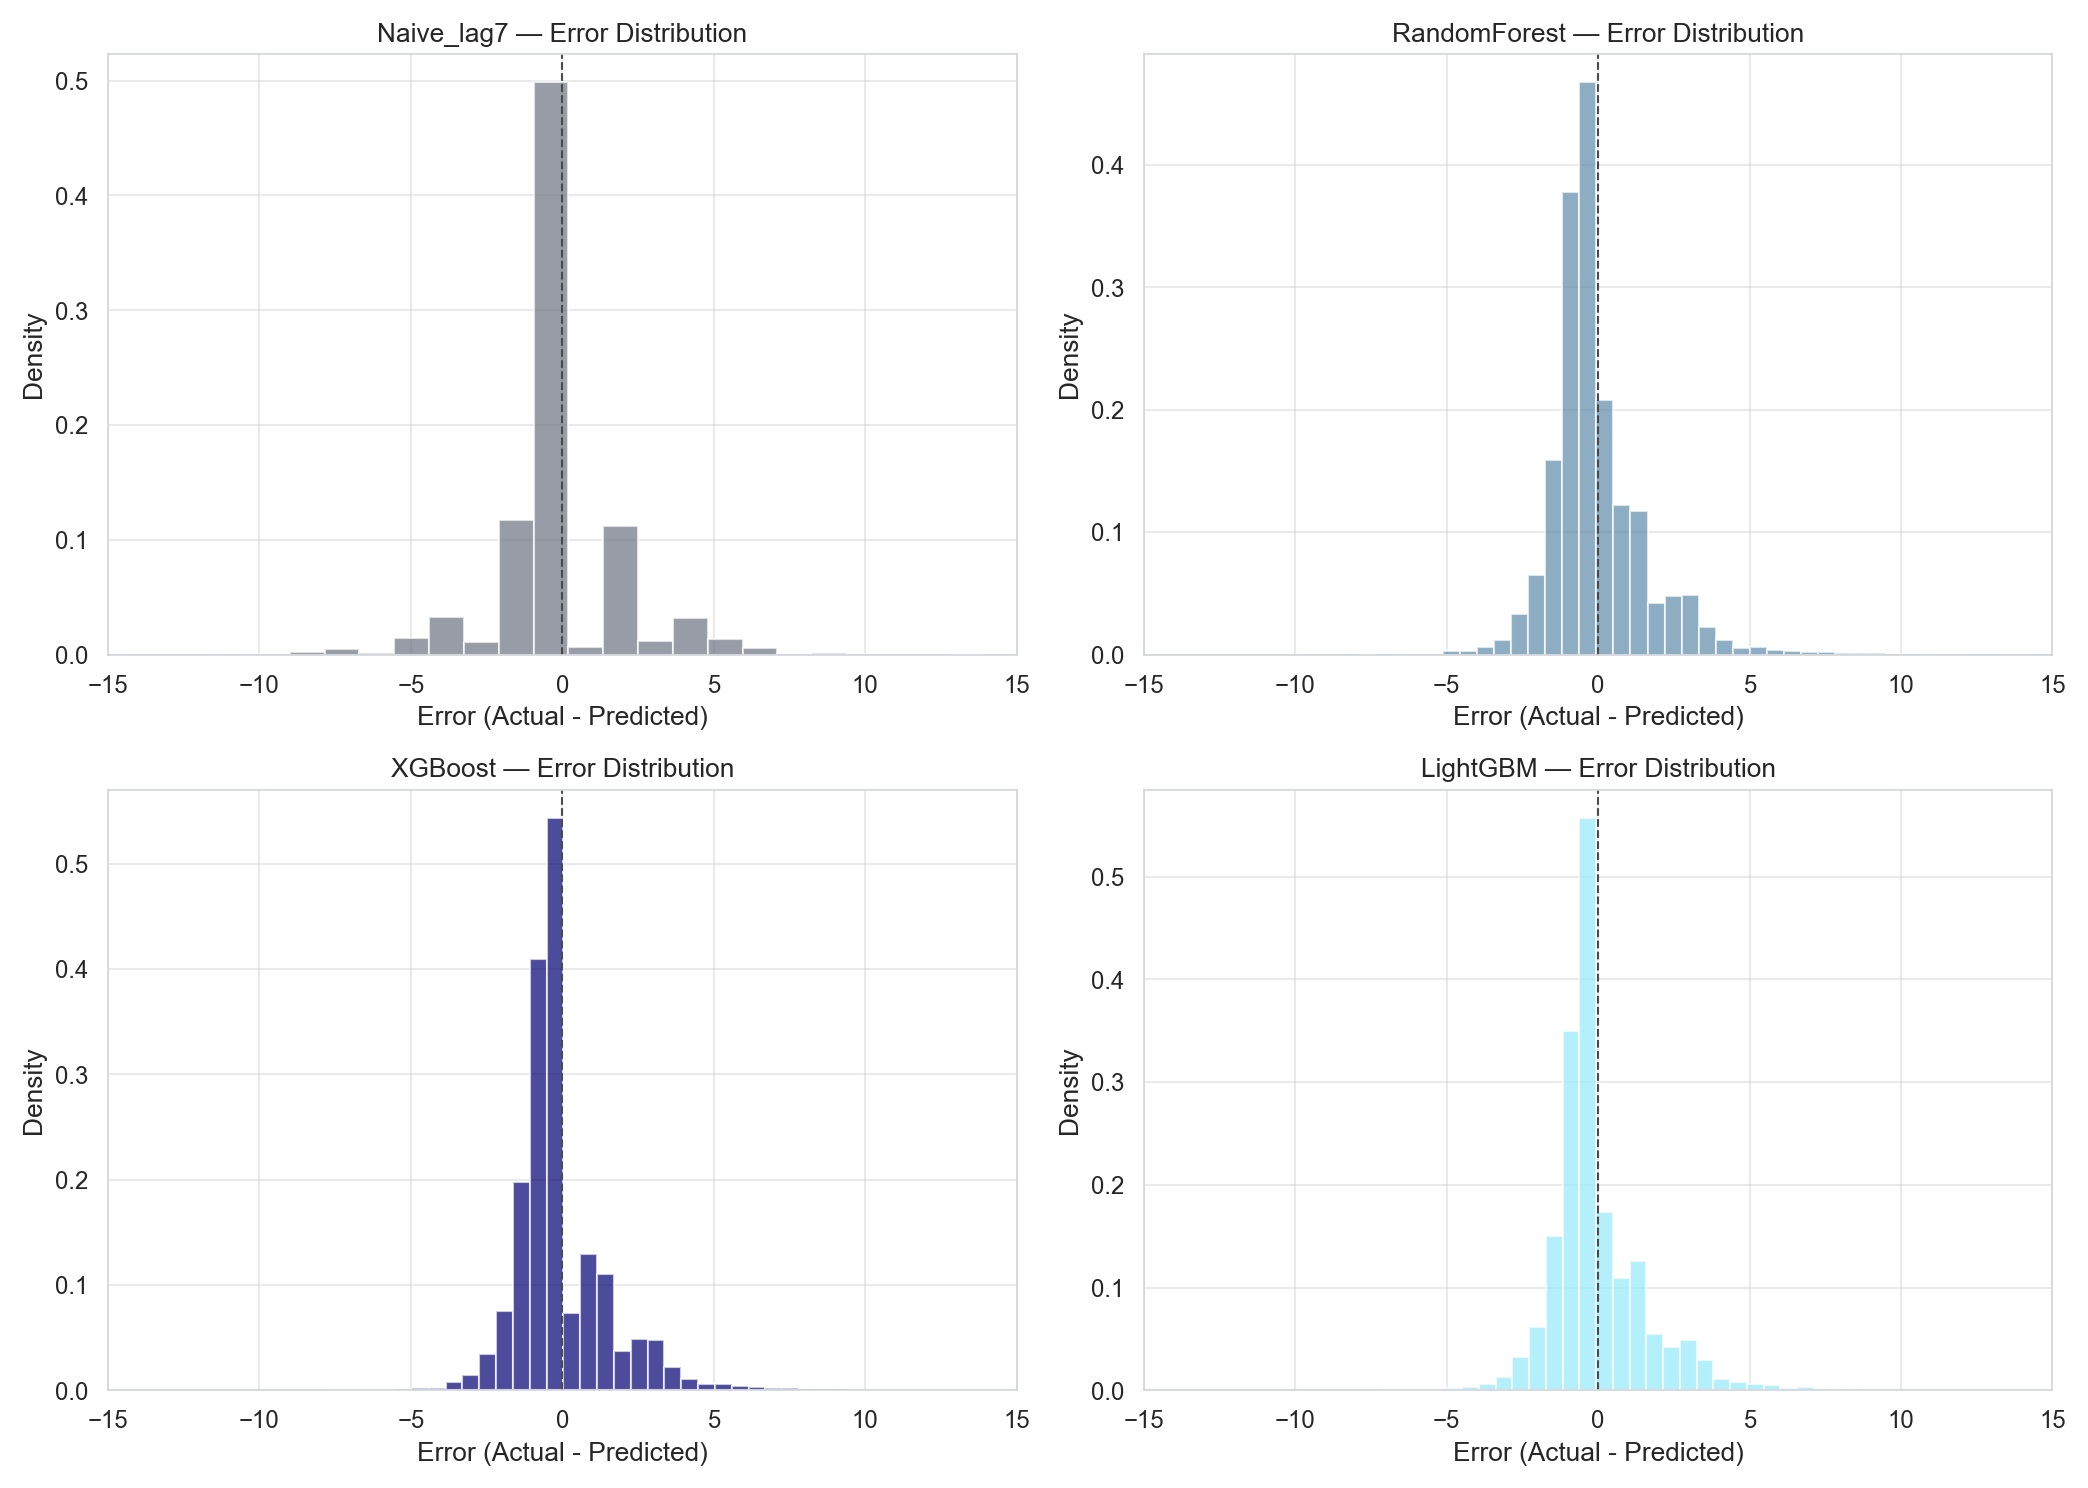

   → Saved 17_error_distributions.png

Per-product RMSE distribution:


       Naive_lag7  RandomForest  XGBoost  LightGBM
count     861.000       861.000  861.000   861.000
mean        2.006         1.454    1.455     1.453
std         1.078         0.752    0.745     0.745
min         0.000         0.041    0.074     0.044
25%         1.317         1.005    1.007     0.995
50%         1.826         1.318    1.317     1.327
75%         2.463         1.752    1.740     1.762
max        10.141         6.766    6.725     6.764


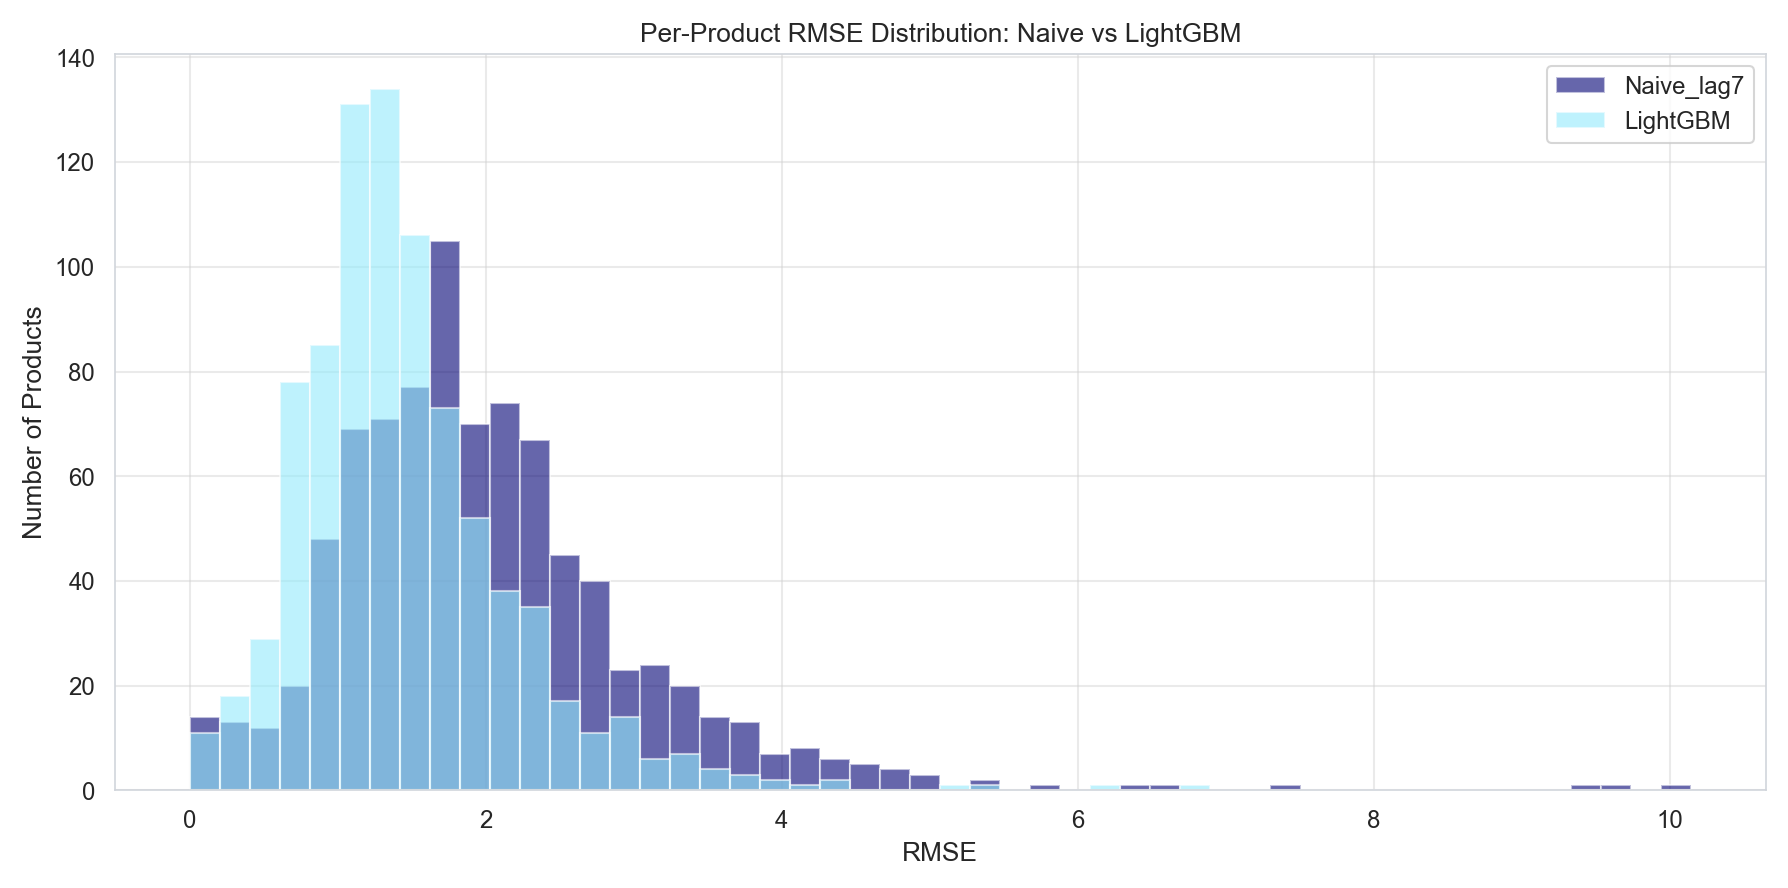

   → Saved 18_per_product_rmse_dist.png

── Top 10 products with most improvement (Naive→LGBM) ──
producto
359    8.682
21     3.247
228    2.789
2      2.613
669    2.224
78     2.163
97     1.848
70     1.753
136    1.738
68     1.592
dtype: float64

── 10 products with least improvement ──
producto
346   -0.083
725   -0.089
422   -0.101
593   -0.196
741   -0.198
521   -0.228
758   -0.251
177   -0.253
401   -0.267
13    -0.792
dtype: float64


In [4]:
print('\n' + '=' * 60)
print('3. ERROR ANALYSIS')
print('=' * 60)

pf = preds.copy()
models = ['Naive_lag7', 'RandomForest', 'XGBoost', 'LightGBM']

# 3.1 Error distribution per model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, m in zip(axes.flat, models):
    errors = pf[TARGET] - pf[m]
    ax.hist(errors, bins=80, edgecolor='white', alpha=0.7, density=True, color=get_model_color(m))
    ax.axvline(x=0, color=ALERT, linewidth=1, linestyle='--')
    ax.set_title(f'{m} \u2014 Error Distribution')
    ax.set_xlabel('Error (Actual - Predicted)')
    ax.set_ylabel('Density')
    ax.set_xlim(-15, 15)
save_fig('17_error_distributions')

# 3.2 Per-product RMSE distribution
print('\nPer-product RMSE distribution:')
prod_rmse = {}
for m in models:
    per_prod = pf.groupby('producto').apply(
        lambda g: np.sqrt(mean_squared_error(g[TARGET], g[m])), include_groups=False
    )
    prod_rmse[m] = per_prod

prod_rmse_df = pd.DataFrame(prod_rmse)
print(prod_rmse_df.describe().round(3))

fig, ax = plt.subplots(figsize=(12, 6))
prod_rmse_df[['Naive_lag7', 'LightGBM']].plot(
    kind='hist', bins=50, alpha=0.6, ax=ax, edgecolor='white',
    color=[PRIMARY, SECONDARY]
)
ax.set_title('Per-Product RMSE Distribution: Naive vs LightGBM')
ax.set_xlabel('RMSE')
ax.set_ylabel('Number of Products')
save_fig('18_per_product_rmse_dist')

# 3.3 Products where ML improves most / least
improvement = prod_rmse_df['Naive_lag7'] - prod_rmse_df['LightGBM']
improvement = improvement.sort_values(ascending=False)
print(f'\n\u2500\u2500 Top 10 products with most improvement (Naive\u2192LGBM) \u2500\u2500')
print(improvement.head(10).round(3))
print(f'\n\u2500\u2500 10 products with least improvement \u2500\u2500')
print(improvement.tail(10).round(3))


### Error by Day of Week & Promo vs Non-Promo Comparison


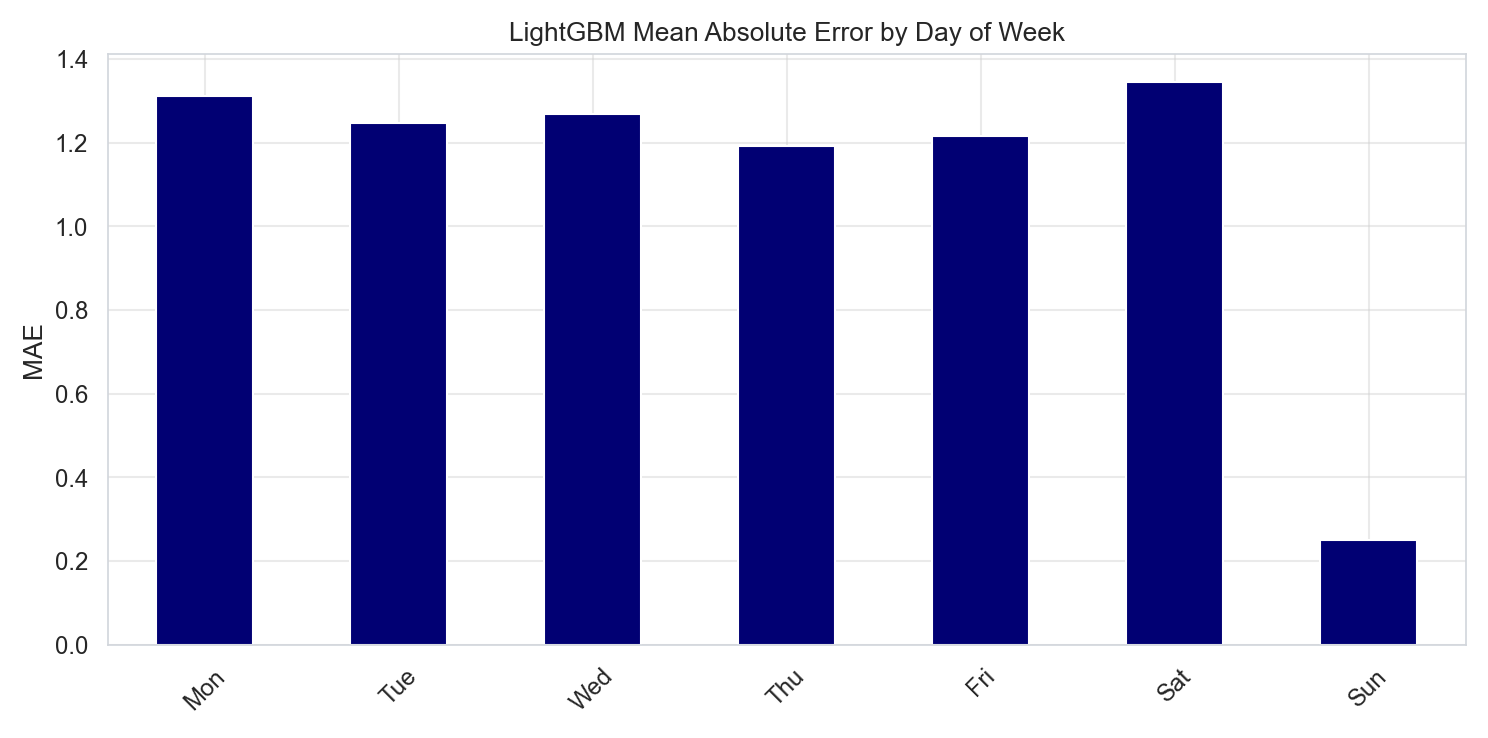

   → Saved 19_mae_by_day_of_week.png

── Detailed Promo vs Non-Promo Metrics ──
                          MAE    MAPE   RMSE  sigma_e
segment   model                                      
Non-Promo LightGBM      1.079  52.016  1.639    1.639
          Naive_lag7    1.237  74.213  2.288    2.288
          RandomForest  1.086  50.184  1.644    1.643
          XGBoost       1.107  50.299  1.641    1.640
Overall   LightGBM      1.097  51.455  1.633    1.633
          Naive_lag7    1.256  74.359  2.277    2.277
          RandomForest  1.098  50.036  1.637    1.636
          XGBoost       1.121  50.012  1.635    1.634
Promo     LightGBM      1.161  49.546  1.609    1.609
          Naive_lag7    1.326  74.856  2.233    2.233
          RandomForest  1.142  49.534  1.611    1.611
          XGBoost       1.171  49.034  1.610    1.610

EVALUATION COMPLETE


In [5]:
# 3.4 Error by day of week
pf_with_dow = pf.merge(
    df[['producto', 'fecha', 'day_of_week']].drop_duplicates(),
    on=['producto', 'fecha'], how='left'
)

dow_errors = {}
for m in ['LightGBM']:
    pf_with_dow['_err'] = np.abs(pf_with_dow[TARGET] - pf_with_dow[m])
    dow_errors[m] = pf_with_dow.groupby('day_of_week')['_err'].mean()

dow_df = pd.DataFrame(dow_errors)
dow_df.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 5))
dow_df.plot(kind='bar', ax=ax, color=PRIMARY, edgecolor='white', legend=False)
ax.set_title('LightGBM Mean Absolute Error by Day of Week')
ax.set_ylabel('MAE')
ax.set_xlabel('')
plt.xticks(rotation=45)
save_fig('19_mae_by_day_of_week')

# 3.5 Promo vs Non-Promo detailed comparison
print('\n\u2500\u2500 Detailed Promo vs Non-Promo Metrics \u2500\u2500')
comparison_rows = []
for label, mask in [('Overall', pf[TARGET] >= 0), ('Non-Promo', pf['en_promo'] == 0), ('Promo', pf['en_promo'] == 1)]:
    subset = pf[mask]
    for m in models:
        metrics = calc_metrics(subset[TARGET], subset[m])
        metrics['segment'] = label
        metrics['model'] = m
        comparison_rows.append(metrics)

comp_df = pd.DataFrame(comparison_rows)
comp_pivot = comp_df.pivot_table(index=['segment', 'model'], values=['MAE', 'RMSE', 'MAPE', 'sigma_e'])
print(comp_pivot.round(3).to_string())
comp_df.to_csv(OUTPUT_DIR / 'promo_comparison.csv', index=False)

print('\n' + '=' * 60)
print('EVALUATION COMPLETE')
print('=' * 60)
